In [1]:
%pip install audioop-lts


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
path =  os.getcwd()
from pathlib import Path
import sys

import_dir = Path.cwd() / "Import_Scripts"   # → /workspaces/.../Import_Scripts
assert import_dir.exists(), f"Not found: {import_dir}"

sys.path.insert(0, str(import_dir))

import PLS
from PLS import *
import pandas as pd
import numpy as np
from scipy.optimize import fsolve
import pickle as pkl
from datetime import datetime

from NIR_ImportExport import *
from NIR_Metrics import *
from NIR_Plots import *
from NIR_Preprocessing import *
from NIR_Training import *
from NIR_Uncertainty import *

os.chdir(path)

pls = pkl.load(open("Uncertainty_Models/CharModel.pkl", 'rb'))
pls_nonchar = pkl.load(open("Uncertainty_Models/NonCharModel.pkl", 'rb'))

user_input = input("Enter your name (It should match the name of the user folder in the folder Users): ")
date_input = input("Enter sample date (in dd/mm/yyyy). This is the date of the samples you want to run: ")
compositions_plot = input("Do you have wet lab compositions available to plot? (Y/N) If N, no wet lab CA predictions will be plotted: ").strip().lower()
print("")
samples_charred = input("If you want to perform pseudo-lignin estimation, samples must be charred. If samples are not charred, please enter N in the next question. \nAre samples charred? (Y/N): ").strip().lower()

In [2]:
from pathlib import Path

In [4]:
file_path = Path("Users") / user_input / "SamplesData.xlsx"
print("Looking for:", file_path.resolve())
assert file_path.exists(), f"Not found: {file_path.resolve()}"
dataset, wavelength, spectra_raw=file_import(file_path,'Reflectance') ; np.nan_to_num(spectra_raw,copy=False)

dates = pd.read_excel(file_path, sheet_name="Names",header=0).loc[:,'Date'].values.astype('datetime64[D]')
# Convert numpy array to list of datetime objects
date_objects = [np.datetime64(date).tolist() for date in dates]
# Replace None in date_objects with datetime.date(2100, 1, 1)
date_objects = [date if date is not None else datetime(2100, 1, 1).date() for date in date_objects]
# Convert datetime objects to string with format "dd/mm/yyyy"
date_strings = np.array([datetime.strftime(date, "%d/%m/%Y") for date in date_objects])
samples_run = date_strings==date_input

sample_names=pd.read_excel(file_path, sheet_name="Names",header=0).loc[:,"Sample Description"].values[samples_run]
spectra_raw_avg=spectra_avg(spectra_raw)[:,samples_run]

# Preprocess the data
low_nm = 948 ; up_nm = 2500
wavelength_red, spectra_red, spectra_raw_red= spectra_red_range(low_nm, up_nm, spectra_raw_avg, wavelength, spectra_raw)

w = 4*4+1 ; p = 2*2 ; spectra_smooth=spectra_smoothing(spectra_red,w,p,deriv=0)

X_test,_ = snv(spectra_smooth) ; X_test = X_test.T

spectra_raw_min, spectra_raw_max=spectra_minmax(spectra_raw) ; spectra_raw_min=spectra_raw_min[:,samples_run] ; spectra_raw_max=spectra_raw_max[:,samples_run]

_, spectra_red_min, _= spectra_red_range(low_nm, up_nm, spectra_raw_min, wavelength, spectra_raw)
_, spectra_red_max, _= spectra_red_range(low_nm, up_nm, spectra_raw_max, wavelength, spectra_raw)

spectra_smooth_min=spectra_smoothing(spectra_red_min,w,p,deriv=0) ; spectra_smooth_max=spectra_smoothing(spectra_red_max,w,p,deriv=0)

X_test_min,_ = snv(spectra_smooth_min) ; X_test_min = X_test_min.T
X_test_max,_ = snv(spectra_smooth_max) ; X_test_max = X_test_max.T

n_test = X_test.shape[0]
n_points = 100
y_hat = np.zeros((n_test,3))
y_pos = np.zeros((n_test, n_points, 3))
y_dens = np.zeros((n_test,n_points,3))
y_hat_min = np.zeros((n_test,3)) ; y_hat_max = np.zeros((n_test,3))

for i in range(n_test):
    print(i+1,"/",n_test)
    y_hat[i] = pls.predict(X_test[i])
    y_hat_min[i] = pls.predict(X_test_min[i]) ; y_hat_max[i] = pls.predict(X_test_max[i])
    f = lambda y: pls.prediction_cdf(X_test[i], y) - 0.025
    g = lambda y: pls.prediction_cdf(X_test[i], y) - 0.975
    y_min = fsolve(f, y_hat[i])
    y_max = fsolve(g, y_hat[i])

    y_pos[i] = np.linspace(y_min, y_max, n_points).reshape(n_points,3)
    for j in range(n_points):
        y_dens[i,j,:] = pls.boot_pdf(X_test[i],y_pos[i,j,:])

spectral_uncertainty_up, spectral_uncertainty_down = uncertainty_estimation_spectra(y_hat, y_hat_min, y_hat_max)
y_ovr = (sample_names, y_hat, y_pos, y_dens)

Looking for: /workspaces/BioLig-NIR-main/Users/ABA/SamplesData.xlsx
1 / 8
2 / 8
3 / 8
4 / 8
5 / 8
6 / 8
7 / 8
8 / 8


In [5]:
if compositions_plot == 'y':
    comp_vector = ['Glucan','Xylan','Galactan','Arabinan','Mannan','ASL','AIL','Ash','Extractives']
    err_vector = [i+'_err' for i in comp_vector]
    compositions = pd.read_excel(file_name, sheet_name="Compositions",header=0).loc[samples_run,comp_vector].values
    compositions_err = pd.read_excel(file_name, sheet_name="Compositions",header=0).loc[samples_run,err_vector].values
    y_comp = np.array([compositions[:,0], np.sum(compositions[:,1:5],axis=1),np.sum(compositions[:,5:7],axis=1)]).T
    y_comp_err = np.array([compositions_err[:,0], np.sum(compositions_err[:,1:5],axis=1),np.sum(compositions_err[:,5:7],axis=1)]).T
else:
    y_comp = np.zeros((n_test,3))
    y_comp_err = np.zeros((n_test,3))

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

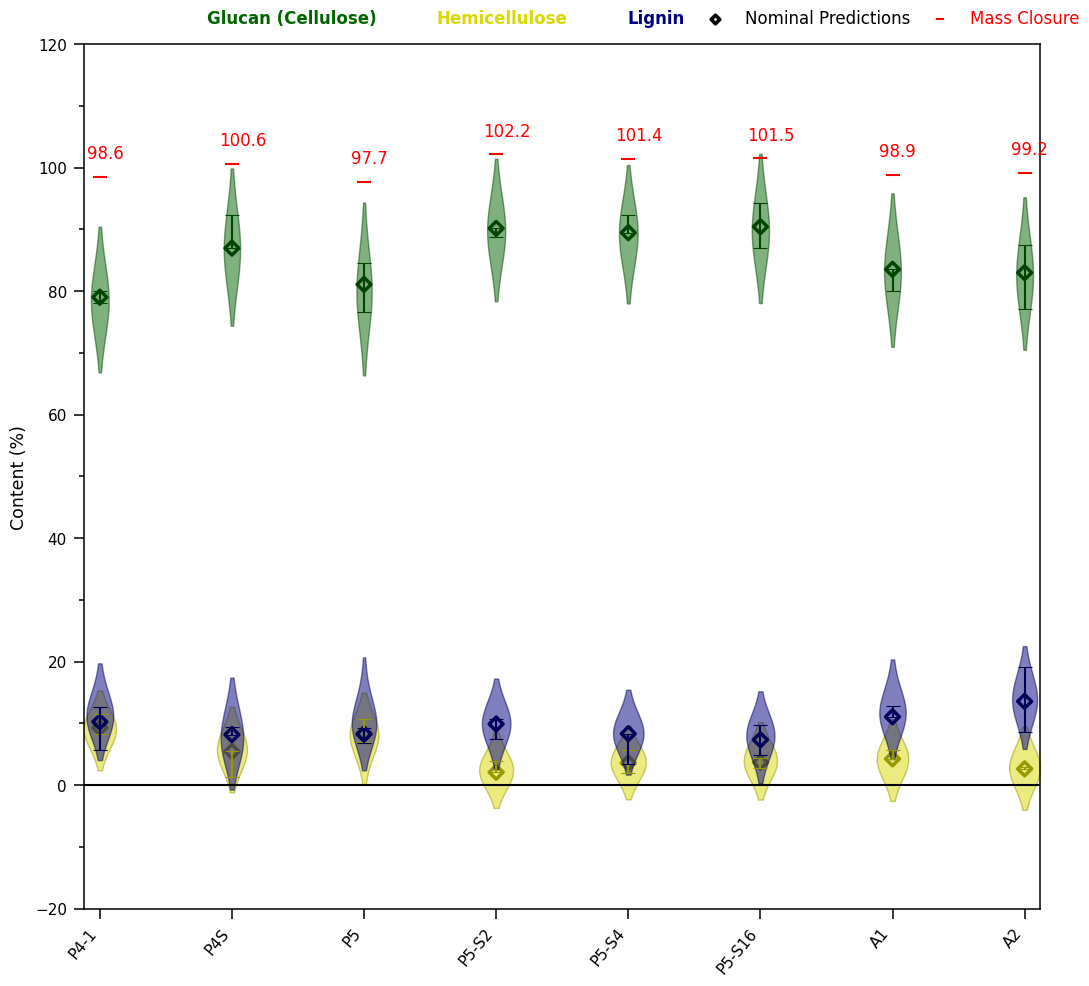

In [6]:
save_loc = "Users\\"+user_input+"\\"+date_input.replace("/", "_")
ha_plt = 'right'; label_rotation = 50

violin_plot(y_pos, y_dens, y_hat, y_comp, sample_names, spectral_uncertainty_up, spectral_uncertainty_down, y_comp_err, sort_uncertainty = False, save_fig = True, save_name = save_loc, ha_plt=ha_plt, label_rotation=label_rotation, plot_show = True)

std = (y_pos[:,-1,:] - y_pos[:,0,:])/(2*1.96)

# Reshape the arrays to have a third dimension
array1_reshaped = y_hat.reshape(n_test, -1, 1)
# array2_reshaped = std.reshape(n_test, -1, 1)
array_3_reshaped = spectral_uncertainty_up.reshape(n_test, -1, 1)
array_4_reshaped = spectral_uncertainty_down.reshape(n_test, -1, 1)

# Concatenate the arrays along the third dimension
result = np.concatenate((array1_reshaped,array_3_reshaped,array_4_reshaped), axis=2)

# Reshape the result back to 2D
result_2d = result.reshape(n_test, -1)
result_2d = np.concatenate((result_2d, std), axis=1)

df = pd.DataFrame(result_2d, index=sample_names, columns=['Glucan',"+","-", 'Hemicellulose',"+","-", 'Lignin',"+","-",u"Glucan \u00B1 (Probability)",u"Hemicellulose \u00B1 (Probability)",u"Lignin \u00B1 (Probability)"])
df.to_csv(save_loc+'Results.csv', index=True)

Performing pseudo-lignin estimation...
1 / 4
2 / 4
3 / 4
4 / 4


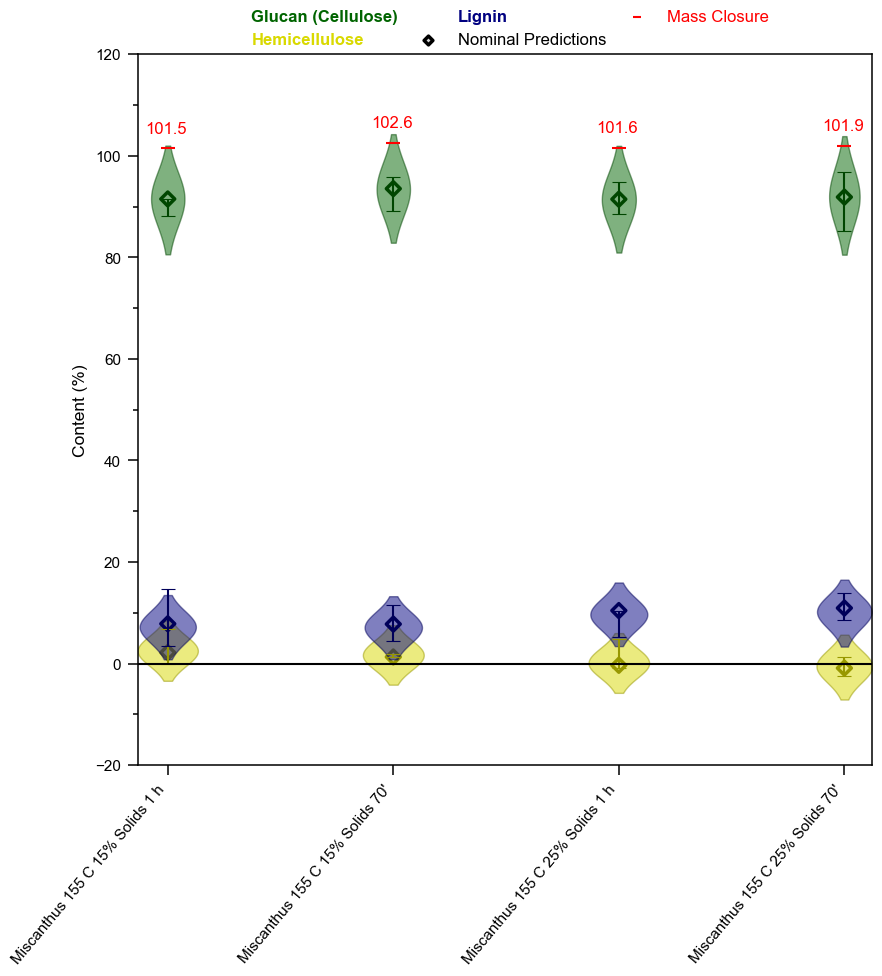

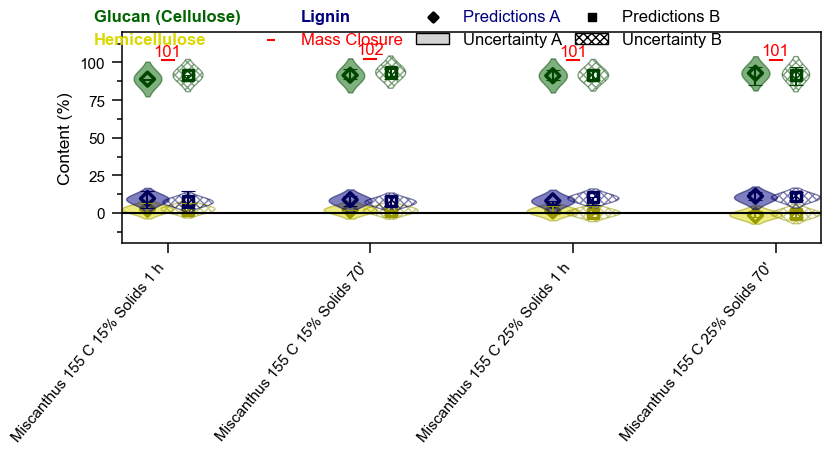

In [14]:
if samples_charred == 'y':
    print("Performing pseudo-lignin estimation...")
    # Preprocess the data
    low_nm = 800 ; up_nm = 2500
    wavelength_red, spectra_red, spectra_raw_red= spectra_red_range(low_nm, up_nm, spectra_raw_avg, wavelength, spectra_raw)

    w = 4*4+1 ; p = 2*2 ; spectra_smooth=spectra_smoothing(spectra_red,w,p,deriv=0)

    X_test,_ = snv(spectra_smooth) ; X_test = X_test.T

    spectra_raw_min, spectra_raw_max=spectra_minmax(spectra_raw) ; spectra_raw_min=spectra_raw_min[:,samples_run] ; spectra_raw_max=spectra_raw_max[:,samples_run]

    _, spectra_red_min, _= spectra_red_range(low_nm, up_nm, spectra_raw_min, wavelength, spectra_raw)
    _, spectra_red_max, _= spectra_red_range(low_nm, up_nm, spectra_raw_max, wavelength, spectra_raw)

    spectra_smooth_min=spectra_smoothing(spectra_red_min,w,p,deriv=0) ; spectra_smooth_max=spectra_smoothing(spectra_red_max,w,p,deriv=0)

    X_test_min,_ = snv(spectra_smooth_min) ; X_test_min = X_test_min.T
    X_test_max,_ = snv(spectra_smooth_max) ; X_test_max = X_test_max.T

    n_test = X_test.shape[0]
    n_points = 100
    y_hat_nonchar = np.zeros((n_test,3))
    y_pos_nonchar = np.zeros((n_test, n_points, 3))
    y_dens_nonchar = np.zeros((n_test,n_points,3))
    y_hat_min_nonchar = np.zeros((n_test,3)) ; y_hat_max_nonchar = np.zeros((n_test,3))

    for i in range(n_test):
        print(i+1,"/",n_test)
        y_hat_nonchar[i] = pls_nonchar.predict(X_test[i])
        y_hat_min_nonchar[i] = pls_nonchar.predict(X_test_min[i]) ; y_hat_max_nonchar[i] = pls_nonchar.predict(X_test_max[i])
        f = lambda y: pls_nonchar.prediction_cdf(X_test[i], y) - 0.025
        g = lambda y: pls_nonchar.prediction_cdf(X_test[i], y) - 0.975
        y_min = fsolve(f, y_hat_nonchar[i])
        y_max = fsolve(g, y_hat_nonchar[i])

        y_pos_nonchar[i] = np.linspace(y_min, y_max, n_points).reshape(n_points,3)
        for j in range(n_points):
            y_dens_nonchar[i,j,:] = pls_nonchar.boot_pdf(X_test[i],y_pos_nonchar[i,j,:])

    spectral_uncertainty_up_nonchar, spectral_uncertainty_down_nonchar = uncertainty_estimation_spectra(y_hat_nonchar, y_hat_min, y_hat_max)
    y_ovr = (sample_names, y_hat_nonchar, y_pos, y_dens)

    violin_plot(y_pos_nonchar, y_dens_nonchar, y_hat_nonchar, y_comp, sample_names, spectral_uncertainty_up_nonchar, spectral_uncertainty_down_nonchar, y_comp_err, sort_uncertainty = False, save_fig = True, save_name = save_loc+'NonChar', ha_plt=ha_plt, label_rotation=label_rotation, plot_show = True)

    violin_plot_compare([y_pos, y_pos_nonchar], [y_dens, y_dens_nonchar], [y_hat, y_hat_nonchar], y_comp, sample_names, [spectral_uncertainty_up,spectral_uncertainty_up_nonchar], [spectral_uncertainty_down, spectral_uncertainty_down_nonchar], y_comp_err, sort_uncertainty = False, save_fig = True, save_name = save_loc, ha_plt=ha_plt, label_rotation=label_rotation, plot_show = True)
    
    std = (y_pos_nonchar[:,-1,:] - y_pos_nonchar[:,0,:])/(2*1.96)

    # Reshape the arrays to have a third dimension
    array1_reshaped = y_hat_nonchar.reshape(n_test, -1, 1)
    # array2_reshaped = std.reshape(n_test, -1, 1)
    array_3_reshaped = spectral_uncertainty_up_nonchar.reshape(n_test, -1, 1)
    array_4_reshaped = spectral_uncertainty_down_nonchar.reshape(n_test, -1, 1)

    # Concatenate the arrays along the third dimension
    result = np.concatenate((array1_reshaped,array_3_reshaped,array_4_reshaped), axis=2)

    # Reshape the result back to 2D
    result_2d = result.reshape(n_test, -1)

    y_pseudolignin = y_hat[:,2] - y_hat_nonchar[:,2]

    result_2d = np.concatenate((result_2d, y_pseudolignin.reshape(n_test,1), std), axis=1)

    df = pd.DataFrame(result_2d, index=sample_names, columns=['Glucan',"+","-", 'Hemicellulose',"+","-", 'Lignin',"+","-", 'Pseudo-Lignin',u"Glucan \u00B1 (Probability)",u"Hemicellulose \u00B1 (Probability)",u"Lignin \u00B1 (Probability)"])
    df.to_csv(save_loc+'NonCharResults.csv', index=True)